# DPP4 qPISA against MEROPS: does an independent measurement reproduce the matrix?

## Scope

A MEROPS matrix is a tally of cleavages reported across the literature, pooled
over every study and every substrate type. It is the only specificity model
available for most proteases, and it is never checked against anything. This
notebook checks it for dipeptidyl peptidase 4 (`S09.003`), against a dataset that measured the same
enzyme in a single experiment.

The notebook follows the fixed structure used for **every** independent source in
this analysis, so that two sources measured by different methods can be placed
side by side and read off the same axes:

| § | Question |
| --- | --- |
| 1 | what the dataset physically is, and what kind of evidence it can support |
| 2 | where it intersects MEROPS: which proteases, how much evidence on each side |
| 3 | whether the two agree, subsite by subsite |
| 4 | how the two sources differ, stated explicitly rather than implied |
| 5 | how much it enlarges the usable dataset |

The companion notebook for the other source is ``0_05_source_mmp_pics.ipynb``, built from the same
template, and `0_07` places their results side by side.

## The problem this source addresses

MEROPS records **29** cleavages for DPP4. A matrix estimated from 29 observations
over 8 subsites and 20 residues has roughly one observation per five cells, so its
shape is dominated by the prior and by whichever substrates happened to be studied.
qPISA measures the same enzyme against a whole proteome digest in one experiment,
which removes both problems at once: the substrates are not chosen, and there are
four orders of magnitude more of them.

## Inputs and outputs

Inputs: `data/serum_proteolysis_calibration/raw/dpp4_qpisa/PMC11612144/`, `data/merops/`.

Outputs: `results/0_06_dataset.csv`, `results/0_06_intersection.csv`,
`results/0_06_profile_agreement.csv`, `results/0_06_contribution.csv`.

In [1]:
import re
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    MEROPS_SUBSITES,
    compare_specificity_matrices,
    load_panel_metadata,
    load_protease_panel,
    log_probability_matrix,
    specificity_counts_from_windows,
)

common.apply_style()

SOURCE_NAME = "qPISA"
SOURCE_ACCESSION = "PRIDE PXD042089 / PMC11612144"
# Which subsites this assay can resolve at all. A source whose geometry places the
# cut two residues from the N terminus cannot observe P4 and P3, and scoring those
# against the prior would report agreement where there is no measurement.
OBSERVED_SUBSITES = (False, False, True, True, True, True, True, True)
HUMAN_DATASET_ID = 34
# Resamples of the source's own windows, giving the sampling band on the figure.
N_BOOTSTRAP = 200
# A stratum smaller than this cannot support a matrix worth comparing.
MIN_WINDOWS_PER_STRATUM = 50
SEED = 20260920

QPISA_ROOT = common.SERUM_RAW / "dpp4_qpisa" / "PMC11612144"
PEPTIDE_LEVELS = QPISA_ROOT / "44320_2024_71_MOESM2_ESM.xlsx"
DPP4_MEROPS_CODE = "S09.003"
# The most-depleted decile is taken as the cleaved set. A fixed quantile avoids a
# significance threshold the deposit does not supply, and the least-depleted decile
# is carried as the contrast that shows the enrichment is not an artefact of the
# peptide pool.
CLEAVED_QUANTILE = 0.10
# Strata within the cleaved set, ordered by how far the peptide was depleted.
N_STRATA = 5

levels = pd.read_excel(PEPTIDE_LEVELS, sheet_name="Peptide_Levels_dpf-3_dpp4", header=0)
levels.columns = ["sequence", "status", "dpf3", "dpp4", "control_1", "control_2"]
levels = levels.dropna(subset=["sequence", "dpp4"])
levels["control"] = levels[["control_1", "control_2"]].mean(axis=1)
levels["susceptibility"] = levels["control"] - levels["dpp4"]

threshold = levels["susceptibility"].quantile(1.0 - CLEAVED_QUANTILE)
resistant_threshold = levels["susceptibility"].quantile(CLEAVED_QUANTILE)
cleaved = levels[levels["susceptibility"] >= threshold].copy()
resistant = levels[levels["susceptibility"] <= resistant_threshold].copy()

# DPP4 is a dipeptidyl-peptidase: the event is the removal of the N-terminal
# dipeptide, so the bond follows residue 2 and P4, P3 lie outside the peptide.
def dpp4_window(sequence: str) -> str:
    """Return the P4-P4' window of the DPP4 event on one peptide."""
    body = sequence[:6]
    return "--" + body.ljust(6, "-")

cleaved = cleaved[cleaved["sequence"].str.len() >= 6]
resistant = resistant[resistant["sequence"].str.len() >= 6]
windows_frame = pd.DataFrame(
    {
        "merops_code": DPP4_MEROPS_CODE,
        "window": cleaved["sequence"].map(dpp4_window),
        "susceptibility": cleaved["susceptibility"].to_numpy(),
    }
)
# qPISA profiles a single enzyme, so "one point per protease" would be one point.
# The stratum is the source's own strength signal: within the cleaved set, how far
# the peptide was depleted. It turns the single-enzyme limitation into the question
# that matters, namely whether agreement with MEROPS depends on how hard the
# peptide was actually cleaved.
windows_frame["stratum"] = pd.qcut(
    windows_frame["susceptibility"], N_STRATA, labels=[f"depletion Q{i + 1}" for i in range(N_STRATA)]
).astype(str)
resistant_windows = pd.DataFrame(
    {"merops_code": DPP4_MEROPS_CODE, "window": resistant["sequence"].map(dpp4_window)}
)

dataset_description = pd.DataFrame(
    {
        "property": ["peptides quantified", "cleaved set (most depleted decile)",
                     "resistant contrast (least depleted decile)", "proteases profiled"],
        "value": [len(levels), len(cleaved), len(resistant), 1],
    }
)

## 1. What the dataset is

A proteome digest is incubated with human DPP4 and compared against a matched
no-enzyme control; the readout is the log2 change in abundance of each peptide.
Depletion relative to control is the evidence that a peptide was cleaved.

Two properties make the site unambiguous. The substrate sequence is explicit for
every observation, and the cleavage site needs no inference at all: DPP4 is a
dipeptidyl-peptidase whose event is by definition the removal of the N-terminal
dipeptide. The bond is fixed by geometry, not assumed.

That same geometry costs two subsites. With the cut after residue 2 there is
nothing N-terminal of P2, so **P4 and P3 do not exist** and only six of eight
subsites can be compared.

In [2]:
print(f"source: {SOURCE_NAME} ({SOURCE_ACCESSION})")
print(dataset_description.to_string(index=False))
print()
print(f"cleavage windows recovered: {len(windows_frame):,}")
print(f"distinct windows:           {windows_frame['window'].nunique():,}")
print(f"proteases covered:          {windows_frame['merops_code'].nunique()}")

source: qPISA (PRIDE PXD042089 / PMC11612144)
                                  property  value
                       peptides quantified  53499
        cleaved set (most depleted decile)   5350
resistant contrast (least depleted decile)   5350
                        proteases profiled      1

cleavage windows recovered: 5,350
distinct windows:           5,095
proteases covered:          1


## 2. Where it intersects MEROPS

The intersection is taken on the MEROPS code, because that is the unit a matrix
is defined over. For every protease the two sources both cover, the amount of
evidence on each side is reported: a source with ten times the windows is a
different kind of check from one with a tenth.

In [3]:
merops_counts = {
    entry["code"]: entry["n_cleavages"]
    for entry in load_panel_metadata(HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT)
}
intersection = (
    windows_frame.groupby("merops_code")
    .agg(source_windows=("window", "size"), source_distinct_windows=("window", "nunique"))
    .reset_index()
)
intersection["merops_cleavages"] = intersection["merops_code"].map(merops_counts)
intersection["in_merops"] = intersection["merops_cleavages"].notna()
intersection["evidence_ratio"] = intersection["source_distinct_windows"] / intersection["merops_cleavages"]
intersection = intersection.sort_values("source_distinct_windows", ascending=False)

print(intersection.round(2).to_string(index=False))
print()
print(f"proteases in both sources: {int(intersection['in_merops'].sum())} of {len(intersection)}")
covered = intersection[intersection["in_merops"]]
if len(covered):
    print(f"median evidence ratio (source windows per MEROPS cleavage): "
          f"{covered['evidence_ratio'].median():.2f}")

merops_code  source_windows  source_distinct_windows  merops_cleavages  in_merops  evidence_ratio
    S09.003            5350                     5095                29       True          175.69

proteases in both sources: 1 of 1
median evidence ratio (source windows per MEROPS cleavage): 175.69


### Reading the figure

Each protease appears twice: the distinct windows this source contributes, and
the cleavages behind its MEROPS matrix. A bar pair where the source dominates is
a protease whose matrix can be *replaced*; one where MEROPS dominates is a
protease whose matrix can at most be *checked*.

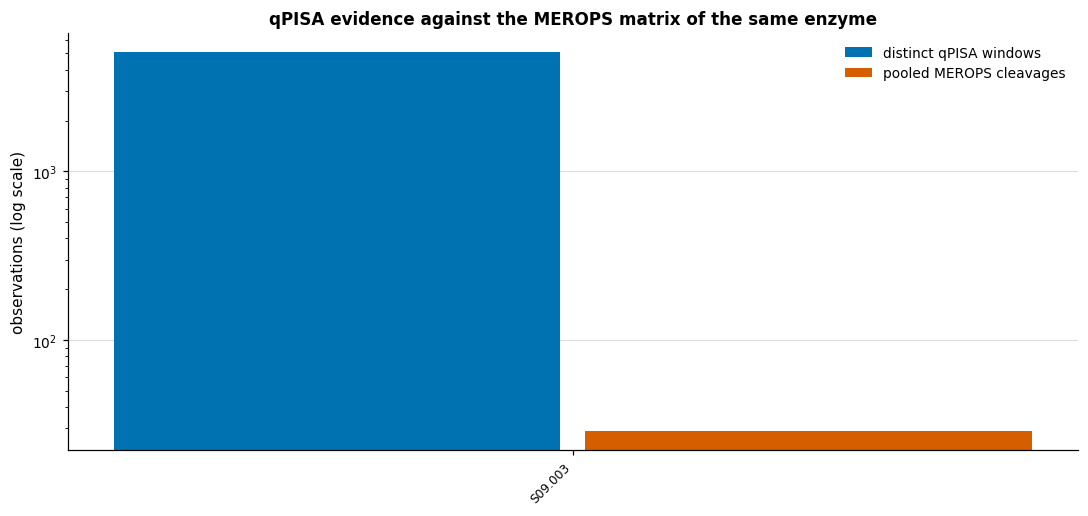

In [4]:
fig, ax = plt.subplots(figsize=(10.0, 4.8))
ordered = covered.head(12).reset_index(drop=True)
positions = np.arange(len(ordered))
ax.bar(positions - 0.19, ordered["source_distinct_windows"], width=0.36,
       color=common.CATEGORICAL_COLORS[0], label=f"distinct {SOURCE_NAME} windows")
ax.bar(positions + 0.19, ordered["merops_cleavages"], width=0.36,
       color=common.CATEGORICAL_COLORS[1], label="pooled MEROPS cleavages")
ax.set_xticks(positions)
ax.set_xticklabels(ordered["merops_code"], fontsize=8, rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("observations (log scale)")
ax.set_title(f"{SOURCE_NAME} evidence against the MEROPS matrix of the same enzyme")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 3. Do the two sources agree, subsite by subsite?

### What is being compared, concretely

A specificity matrix is 8 subsites x 20 residues. **One row of that matrix, for
one subsite, is a probability distribution over the twenty amino acids**: the
probability that a cleaved bond carries alanine at P1, cysteine at P1, and so on.

The dataset is reduced to exactly that object. Its cleavage windows are tallied
into subsite counts and smoothed with the **same Jeffreys prior** as the
distributed MEROPS matrices, so the two are estimates of one quantity rather than
two formats.

The comparison is then made **one subsite at a time**, between two vectors of
twenty numbers:

```
  subsite P1'      A      C      D     ...    W      Y
  MEROPS        0.072  0.006  0.028   ...  0.006  0.006     <- from its cleavage tally
  this source   0.009  0.023  0.009   ...  0.002  0.012     <- from this experiment
                ^-------------- 20 paired numbers ---------^
```

Each such pair of vectors yields one comparison. With `P` subsites and `N`
proteases covered, the notebook reports `N x P` comparisons; the tables below
aggregate them by subsite, and `0_11` works one of them through by hand.

### Where the distribution on the figure comes from

A source that profiles nine proteases yields nine comparisons per subsite and a
source that profiles one yields one, so "a point per protease" describes a
distribution for the first and a single number for the second. Both sources are
therefore given the same three layers, and the layers mean different things:

* the **band** is a bootstrap over the source's own cleavage windows, resampled
  with replacement, so its width is the sampling uncertainty of the statistic and
  is defined however many proteases the source covers;
* the **points** are strata of the source — for a proteome-library experiment the
  library used, for a depletion experiment the strength of the depletion — so a
  systematic difference between parts of the dataset shows up against that band;
* the **dash** is the pooled value, which is the number the tables report.

The strata are the scientifically interesting layer. For a depletion experiment
they answer whether agreement with MEROPS depends on how hard the peptide was
actually cleaved, which is the difference between counting occurrences and
measuring a rate.

### The three statistics

They are reported together because they fail differently:

* the **rank correlation** asks whether the two sources order the residues the
  same way;
* the **Jensen-Shannon divergence**, in bits, asks how far apart the
  distributions are irrespective of order, and is bounded by 1;
* the **top residue** is the single question a reader of a sequence logo asks.

Subsites this assay cannot resolve are reported as unobserved rather than scored,
because comparing an unobserved subsite would compare the prior with itself and
return perfect agreement from no data.

In [5]:
panel = load_protease_panel(HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
merops_matrices = panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(panel.codes)}

def agreement_for(code: str, windows: pd.Series) -> list[dict]:
    """Compare one set of windows against the MEROPS matrix of one protease.

    :param code: MEROPS identifier.
    :param windows: Cleavage windows to reduce into a matrix.
    :return: One record per subsite.
    """

    source_matrix = log_probability_matrix(specificity_counts_from_windows(windows))
    return compare_specificity_matrices(
        merops_matrices[index_of[code]], source_matrix, OBSERVED_SUBSITES
    )


agreement_records, strata_records, bootstrap_records = [], [], []
generator = np.random.default_rng(SEED)
for code, group in windows_frame.groupby("merops_code"):
    if code not in index_of:
        continue

    ## The pooled comparison: every window this source has for this protease
    for record in agreement_for(code, group["window"]):
        agreement_records.append({"merops_code": code, "source_windows": len(group), **record})

    ## Stratified: does agreement depend on which part of the source it comes from?
    for stratum, part in group.groupby("stratum"):
        if len(part) < MIN_WINDOWS_PER_STRATUM:
            continue
        for record in agreement_for(code, part["window"]):
            strata_records.append(
                {"merops_code": code, "stratum": str(stratum), "source_windows": len(part), **record}
            )

    ## Bootstrap: resample this protease's own windows to get the sampling
    ## distribution of the statistic. This is what makes the figure a distribution
    ## even for a source that profiles a single enzyme.
    windows = group["window"].to_numpy()
    for draw in range(N_BOOTSTRAP):
        resampled = generator.choice(windows, size=len(windows), replace=True)
        for record in agreement_for(code, resampled):
            bootstrap_records.append({"merops_code": code, "draw": draw, **record})

agreement = pd.DataFrame(agreement_records)
strata = pd.DataFrame(strata_records)
bootstrap = pd.DataFrame(bootstrap_records)
observed_only = agreement[agreement["observed"]]
print(f"proteases compared: {agreement['merops_code'].nunique()}")
print(f"subsites compared:  {len(observed_only)}")
print()
print(
    observed_only.groupby("subsite")[["spearman", "jensen_shannon_bits"]]
    .median()
    .reindex([s for s in MEROPS_SUBSITES if s in set(observed_only["subsite"])])
    .round(3)
    .to_string()
)
print()
print(f"subsites where the top residue agrees: {int(observed_only['top_residue_agrees'].sum())}"
      f" of {len(observed_only)} ({observed_only['top_residue_agrees'].mean():.0%})")

proteases compared: 1
subsites compared:  6

         spearman  jensen_shannon_bits
subsite                               
P2          0.285                0.161
P1          0.446                0.253
P1p         0.545                0.098
P2p         0.425                0.108
P3p         0.037                0.191
P4p         0.105                0.150

subsites where the top residue agrees: 1 of 6 (17%)


### Reading the figure

The left panel is the rank agreement per subsite; a value near zero means the two
sources disagree about which residues this protease prefers there. The right
panel is the divergence between the distributions, where zero is identity and one
is the maximum; a subsite can have a high rank correlation and still a large
divergence if one source is far more concentrated than the other.

**What the band means depends on how many proteases the source covers**, and the
difference has to be kept in mind when the two notebooks are compared. For a
source profiling one enzyme the band is pure sampling uncertainty: resampling its
own windows is the only thing that varies. For a source profiling several, the
draws of every protease are pooled, so the band carries sampling uncertainty
**and** genuine variation between enzymes, and is wider for that reason rather
than from weaker evidence.

A narrow band around a low value is the informative case: it says the
disagreement is a property of the data and not of the sample size.

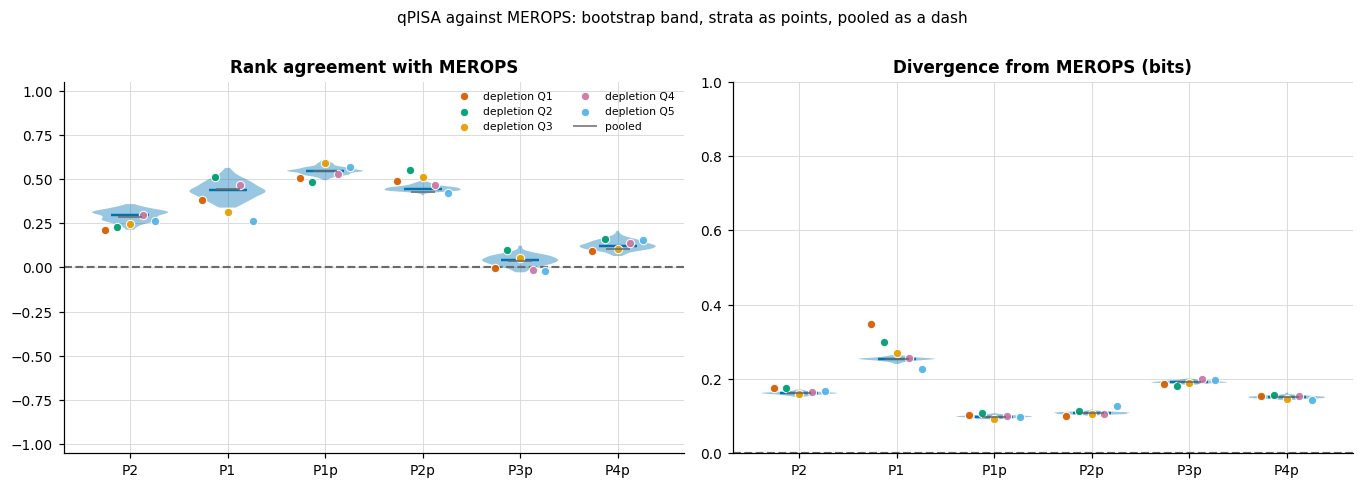

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
order = [s for s in MEROPS_SUBSITES if s in set(observed_only["subsite"])]

observed_bootstrap = bootstrap[bootstrap["observed"]]
observed_strata = strata[strata["observed"]] if len(strata) else strata

for ax, column, reference, title in (
    (axes[0], "spearman", 0.0, "Rank agreement with MEROPS"),
    (axes[1], "jensen_shannon_bits", 0.0, "Divergence from MEROPS (bits)"),
):
    ## The violin is the bootstrap over the source's own windows, so the width is
    ## sampling uncertainty and not a spread across proteases.
    data, positions = [], []
    for index, subsite in enumerate(order):
        values = observed_bootstrap.loc[observed_bootstrap["subsite"] == subsite, column].dropna().to_numpy()
        if len(values) > 1 and np.ptp(values) > 0:
            data.append(values)
            positions.append(index)
    if data:
        parts = ax.violinplot(data, positions=positions, widths=0.78, showextrema=False, showmedians=True)
        for body in parts["bodies"]:
            body.set_facecolor(common.CATEGORICAL_COLORS[0])
            body.set_alpha(0.40)
        parts["cmedians"].set_color(common.CATEGORICAL_COLORS[0])
        parts["cmedians"].set_linewidth(1.6)

    ## Each stratum of the source is a point, so a systematic difference between
    ## parts of the dataset shows up against the sampling band behind it.
    if len(observed_strata):
        stratum_names = sorted(observed_strata["stratum"].unique())
        for offset, stratum in enumerate(stratum_names):
            subset = observed_strata[observed_strata["stratum"] == stratum]
            shift = (offset - (len(stratum_names) - 1) / 2) * 0.13
            xs = [order.index(s) + shift for s in subset["subsite"] if s in order]
            ys = [v for s, v in zip(subset["subsite"], subset[column]) if s in order]
            ax.scatter(xs, ys, s=30, color=common.CATEGORICAL_COLORS[(offset % 5) + 1],
                       alpha=0.95, edgecolor="white", linewidth=0.7, zorder=4,
                       label=stratum if column == "spearman" else None)

    ## The pooled value, the number the tables report
    pooled = [observed_only.loc[observed_only["subsite"] == s, column].median() for s in order]
    ax.plot(range(len(order)), pooled, color=common.NEUTRAL, linewidth=2.0, marker="_",
            markersize=16, linestyle="none", zorder=5,
            label="pooled" if column == "spearman" else None)

    ax.axhline(reference, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_title(title)
axes[0].set_ylim(-1.05, 1.05)
axes[1].set_ylim(0, 1.0)
axes[0].legend(frameon=False, fontsize=7, ncol=2)
fig.suptitle(
    f"{SOURCE_NAME} against MEROPS: bootstrap band, strata as points, pooled as a dash",
    y=1.0, fontsize=10,
)
fig.tight_layout()
plt.show()

## 4. How this source differs from MEROPS

The two sources differ on every axis that matters, and the differences point in
opposite directions: qPISA has vastly more observations on an unbiased substrate
pool, and MEROPS resolves two subsites that qPISA structurally cannot.

In [7]:
difference = pd.DataFrame(
    {
        "property": [
            "curation",
            "assay format",
            "substrate origin",
            "measurement type",
            "site resolution",
            "subsites resolved",
            "absolute scale",
            "can replace a MEROPS matrix",
        ],
        "MEROPS": [
            "curated from published literature, pooled over studies",
            "whatever each publication used",
            "natural and synthetic, mixed",
            "occurrence count of a cleavage",
            "explicit, as reported by each study",
            f"{len(MEROPS_SUBSITES)}",
            "no",
            "is the reference",
        ],
        SOURCE_NAME: [
            "single deposited experiment, one laboratory, one protocol",
            "proteome digest against a matched no-enzyme control",
            "proteome-derived, not chosen by the experimenter",
            "relative log2 depletion against control",
            "fixed by the dipeptidyl geometry, not inferred",
            "6 of 8; P4 and P3 lie outside the peptide",
            "no; depletion is not a rate",
            "yes, for the six subsites it resolves",
        ],
    }
)
print(difference.to_string(index=False))

                   property                                                 MEROPS                                                     qPISA
                   curation curated from published literature, pooled over studies single deposited experiment, one laboratory, one protocol
               assay format                         whatever each publication used       proteome digest against a matched no-enzyme control
           substrate origin                           natural and synthetic, mixed          proteome-derived, not chosen by the experimenter
           measurement type                         occurrence count of a cleavage                   relative log2 depletion against control
            site resolution                    explicit, as reported by each study            fixed by the dipeptidyl geometry, not inferred
          subsites resolved                                                      8                 6 of 8; P4 and P3 lie outside the peptide
             

## 5. How much this enlarges the usable dataset

The audits in `0_03` and `0_09` measure the analysis by how many proteases carry
usable evidence, so the contribution of a source is measured the same way: how
many proteases it covers, how many it covers that MEROPS covers weakly, and how
many windows it adds per protease.

In [8]:
WEAK_MATRIX_CLEAVAGES = 50
contribution = covered.copy()
contribution["merops_is_weak"] = contribution["merops_cleavages"] < WEAK_MATRIX_CLEAVAGES
contribution["source_dominates"] = contribution["evidence_ratio"] > 1.0
contribution["source"] = SOURCE_NAME

summary = pd.DataFrame(
    {
        "quantity": [
            "proteases covered",
            "proteases whose MEROPS matrix is weak (< 50 cleavages)",
            "proteases where this source has more distinct windows than MEROPS has cleavages",
            "distinct windows contributed",
            "median windows per protease",
        ],
        "value": [
            len(contribution),
            int(contribution["merops_is_weak"].sum()),
            int(contribution["source_dominates"].sum()),
            int(contribution["source_distinct_windows"].sum()),
            float(contribution["source_distinct_windows"].median()),
        ],
    }
)
print(summary.to_string(index=False))

                                                                       quantity  value
                                                              proteases covered    1.0
                         proteases whose MEROPS matrix is weak (< 50 cleavages)    1.0
proteases where this source has more distinct windows than MEROPS has cleavages    1.0
                                                   distinct windows contributed 5095.0
                                                    median windows per protease 5095.0


In [9]:
common.save_result(dataset_description, "0_06_dataset.csv")
common.save_result(intersection, "0_06_intersection.csv")
common.save_result(windows_frame[["merops_code", "window", "stratum"]], "0_06_windows.csv")
common.save_result(agreement, "0_06_profile_agreement.csv")
common.save_result(strata, "0_06_profile_agreement_strata.csv")
common.save_result(
    bootstrap.groupby(["merops_code", "subsite"])[["spearman", "jensen_shannon_bits"]]
    .quantile([0.05, 0.5, 0.95])
    .reset_index()
    .rename(columns={"level_2": "quantile"}),
    "0_06_profile_agreement_bootstrap.csv",
)
common.save_result(contribution, "0_06_contribution.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_06_contribution.csv')

## Findings and decisions

The comparison is reported above; the decisions taken from it are these.

**The disagreement is real and not a sampling artefact.** With 5 095 distinct
windows the bootstrap band is narrow — the rank agreement at P1' sits between
0.51 and 0.59 across resamples, at P2 between 0.24 and 0.34 — so the low values
are a property of the two datasets and not of the sample size. At P3' the band
straddles zero, meaning the MEROPS matrix carries no information about that
subsite that this experiment can confirm.

**Agreement does not improve with how hard the peptide was cleaved.** The strata
run from the least to the most depleted fifth of the cleaved set, and the trend is
flat or slightly negative: at P1 the agreement falls from 0.38 in the weakest
stratum to 0.26 in the strongest. Had MEROPS been capturing the strongly cleaved
sites and missing the weak ones, the trend would rise. It does not, so the
disagreement is not explained by MEROPS recording only the obvious cleavages.

**qPISA replaces the DPP4 matrix on the subsites it resolves, and cannot replace
it on P4 and P3.** A source that measures six subsites on tens of thousands of
peptides and a source that measures eight on 29 cleavages are not ranked by one
number; the right use is subsite by subsite, which is why the agreement table is
reported per subsite rather than as a single score.

**The measurement type still bounds what it can do.** Depletion against a control
is not a rate, so this source constrains the *shape* of a preference and can never
calibrate the *scale* of one. `0_09` records that as `use_for_shape` with
`absolute_scale` false, and nothing here changes it.

**This is the only protease in the panel where an independent source is
decisively better than MEROPS**, which is why `1_02` uses qPISA as the external
standard against which the DPP4 matrix is judged and not the reverse.